<a href="https://colab.research.google.com/github/lorida0777/Recommendation_services_hospitaliers/blob/main/Nlp_hospital_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import des librairies

In [18]:
# ───────────────── INSTALLATION PROPRE COLAB ─────────────────

# supprimer librairies conflictuelles
!pip uninstall -y transformers tensorflow tensorflow-decision-forests

# installer versions compatibles
!pip install -q tensorflow==2.19.0
!pip install -q transformers==4.41.2
!pip install -q scikit-learn nltk seaborn joblib

print("✅ Installation terminée - Redémarre maintenant le runtime")

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
✅ Installation terminée - Redémarre maintenant le runtime


In [19]:
import os
import re
import time
import warnings
warnings.filterwarnings("ignore")

# Data
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Transformers
from transformers import AutoTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Sauvegarde
import joblib

print("✅ Librairies chargées")
print("TensorFlow :", tf.__version__)

✅ Librairies chargées
TensorFlow : 2.19.0


Chargement du Dataset

In [20]:
# ── Option A : Upload manuel dans Colab ─────────────────────────────────────
from google.colab import files
uploaded = files.upload()          # sélectionner drugsComTest_raw.csv
df = pd.read_csv('drugsComTrain_raw.csv')

# ── Option B : Depuis Google Drive ──────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/dataset/drugsComTest_raw.csv')

print(f"Dimensions : {df.shape}")
print(f"Colonnes   : {list(df.columns)}")
df.head(3)

Saving drugsComTrain_raw.csv to drugsComTrain_raw (2).csv
Dimensions : (161297, 7)
Colonnes   : ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17


Exploration des données (EDA)

In [21]:
# ── Infos générales ──────────────────────────────────────────────────────────
print("=== Types et valeurs manquantes ===")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

=== Types et valeurs manquantes ===
uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

Valeurs manquantes :
uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64


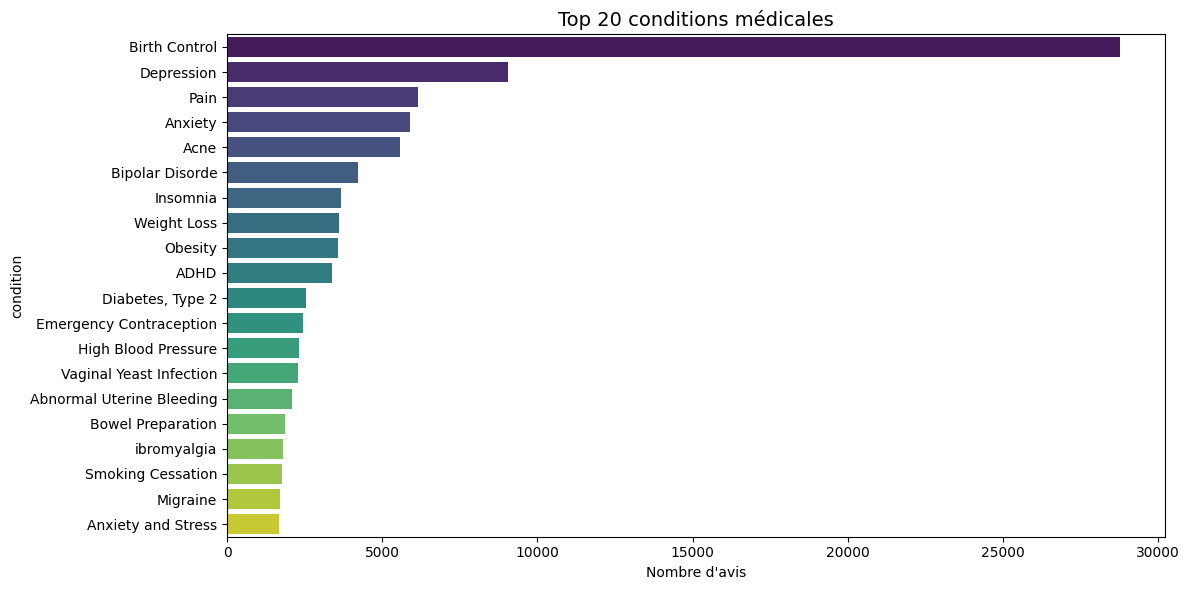


Nombre total de conditions uniques : 884


In [22]:
# ── Distribution des conditions (Top 20) ────────────────────────────────────
top20 = df['condition'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top20.values, y=top20.index, palette='viridis')
plt.title("Top 20 conditions médicales", fontsize=14)
plt.xlabel("Nombre d'avis")
plt.tight_layout()
plt.show()

print(f"\nNombre total de conditions uniques : {df['condition'].nunique()}")

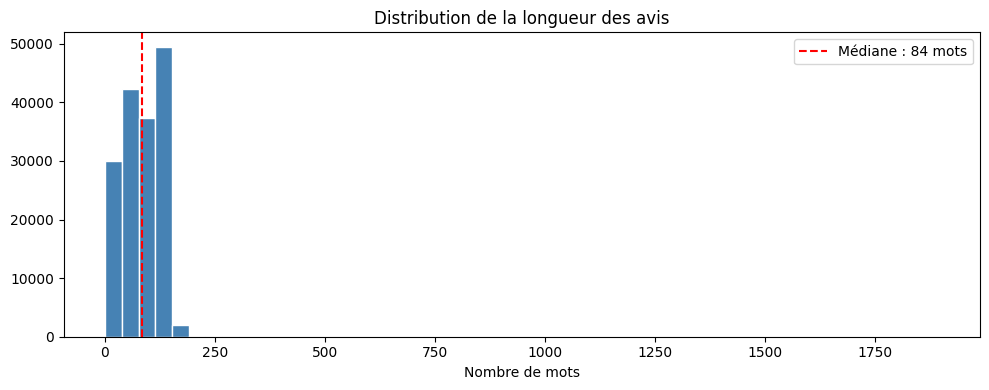

count    161297.000000
mean         84.699802
std          45.044833
min           1.000000
25%          48.000000
50%          84.000000
75%         126.000000
max        1894.000000
Name: review_length, dtype: float64


In [23]:
# ── Longueur des avis ────────────────────────────────────────────────────────
df['review_length'] = df['review'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(df['review_length'].median(), color='red', linestyle='--',
            label=f"Médiane : {df['review_length'].median():.0f} mots")
plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de mots")
plt.legend()
plt.tight_layout()
plt.show()

print(df['review_length'].describe())

Mapping Conditions → Services Hospitaliers

In [24]:
# ── Table de correspondance ──────────────────────────────────────────────────
SERVICE_MAP = {
    # Psychiatrie
    'Depression'                    : 'Psychiatry',
    'Anxiety'                       : 'Psychiatry',
    'Bipolar Disorde'               : 'Psychiatry',
    'Bipolar Disorder'              : 'Psychiatry',
    'Insomnia'                      : 'Psychiatry',
    'ADHD'                          : 'Psychiatry',
    'Anxiety and Stress'            : 'Psychiatry',
    'Schizophrenia'                 : 'Psychiatry',
    'Post Traumatic Stress Disorder': 'Psychiatry',
    'Panic Disorder'                : 'Psychiatry',
    # Neurologie
    'Migraine'                      : 'Neurology',
    'Epilepsy'                      : 'Neurology',
    'Multiple Sclerosis'            : 'Neurology',
    # Gynécologie
    'Birth Control'                 : 'Gynecology',
    'Emergency Contraception'       : 'Gynecology',
    'Abnormal Uterine Bleeding'     : 'Gynecology',
    'Endometriosis'                 : 'Gynecology',
    'Menstrual Disorders'           : 'Gynecology',
    # Dermatologie
    'Acne'                          : 'Dermatology',
    'Rosacea'                       : 'Dermatology',
    'Eczema'                        : 'Dermatology',
    'Psoriasis'                     : 'Dermatology',
    'Skin Rash'                     : 'Dermatology',
    # Endocrinologie
    'Weight Loss'                   : 'Endocrinology',
    'Obesity'                       : 'Endocrinology',
    'Diabetes, Type 2'              : 'Endocrinology',
    'Diabetes, Type 1'              : 'Endocrinology',
    'Hypothyroidism'                : 'Endocrinology',
    # Cardiologie
    'High Blood Pressure'           : 'Cardiology',
    'Heart Failure'                 : 'Cardiology',
    'Atrial Fibrillation'           : 'Cardiology',
    'High Cholesterol'              : 'Cardiology',
    'Angina'                        : 'Cardiology',
    # Pneumologie
    'Smoking Cessation'             : 'Pulmonology',
    'Asthma'                        : 'Pulmonology',
    'COPD'                          : 'Pulmonology',
    # Urologie / Infectiologie
    'Urinary Tract Infection'       : 'Urology',
    'Vaginal Yeast Infection'       : 'Urology',
    'Bacterial Vaginosis'           : 'Urology',
    # Gastro-entérologie
    "Crohn's Disease, Maintenance"  : 'Gastroenterology',
    "Crohn's Disease"               : 'Gastroenterology',
    'Bowel Preparation'             : 'Gastroenterology',
    'Irritable Bowel Syndrome'      : 'Gastroenterology',
    'Ulcerative Colitis'            : 'Gastroenterology',
    'GERD'                          : 'Gastroenterology',
    # Rhumatologie / Douleur
    'Pain'                          : 'Rheumatology',
    'ibromyalgia'                   : 'Rheumatology',
    'Fibromyalgia'                  : 'Rheumatology',
    'Rheumatoid Arthritis'          : 'Rheumatology',
    'Osteoarthritis'                : 'Rheumatology',
    'Back Pain'                     : 'Rheumatology',
    # Oncologie
    'Cancer'                        : 'Oncology',
    'Breast Cancer'                 : 'Oncology',
    'Prostate Cancer'               : 'Oncology',
}

df['service'] = df['condition'].map(SERVICE_MAP)
df_mapped = df.dropna(subset=['service']).copy()

print(f"Lignes après mapping : {len(df_mapped)}")
print("\nDistribution par service :")
print(df_mapped['service'].value_counts())

Lignes après mapping : 106387

Distribution par service :
service
Gynecology          34255
Psychiatry          28510
Rheumatology        10786
Endocrinology        9871
Dermatology          6883
Gastroenterology     4193
Urology              3590
Cardiology           3385
Neurology            2750
Pulmonology          2164
Name: count, dtype: int64


Services conservés : ['Gynecology', 'Psychiatry', 'Rheumatology', 'Endocrinology', 'Dermatology', 'Gastroenterology', 'Urology', 'Cardiology', 'Neurology', 'Pulmonology']
Lignes finales     : 106387


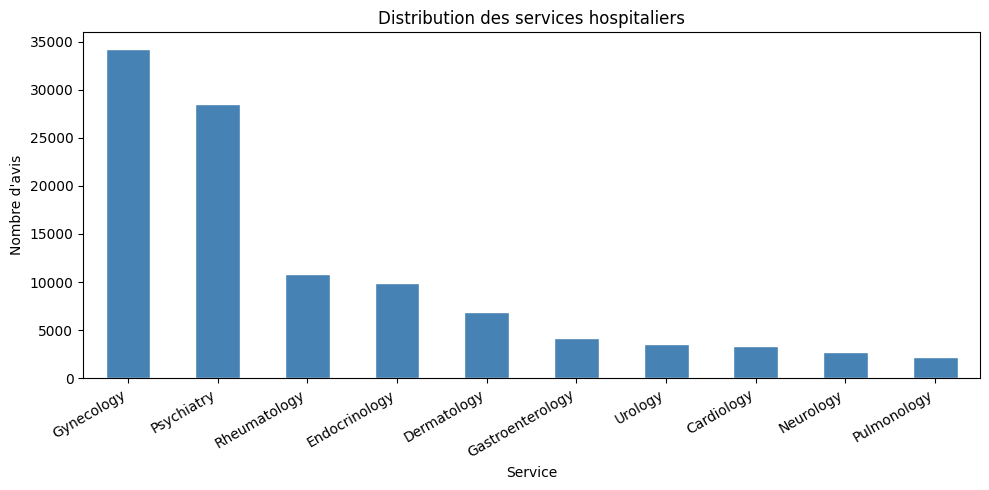

In [25]:
# ── Filtrer les services avec au moins 100 avis ──────────────────────────────
MIN_SAMPLES = 100
counts = df_mapped['service'].value_counts()
valid  = counts[counts >= MIN_SAMPLES].index
df_clean = df_mapped[df_mapped['service'].isin(valid)].copy()

print(f"Services conservés : {list(valid)}")
print(f"Lignes finales     : {len(df_clean)}")

plt.figure(figsize=(10, 5))
df_clean['service'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Distribution des services hospitaliers")
plt.xlabel("Service")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

 Nettoyage & Préprocessing NLP

In [26]:
# ── Outils NLP ───────────────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """
    Pipeline de nettoyage :
    1. Décodage entités HTML
    2. Minuscules
    3. Suppression ponctuation / chiffres
    4. Suppression stopwords
    5. Lemmatisation
    """
    # 1. Entités HTML
    text = re.sub(r'&#039;', "'", text)
    text = re.sub(r'&amp;',  '&', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    # 2. Minuscules
    text = text.lower()
    # 3. Garder uniquement les lettres
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Tokenisation + stopwords
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    # 5. Lemmatisation
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Test
sample = df_clean['review'].iloc[0]
print("AVANT :", sample[:200])
print("\nAPRÈS :", clean_text(sample[:200]))

AVANT : "My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of

APRÈS : son halfway fourth week intuniv became concerned began last week started taking highest dose two day could hardly get


In [27]:
# ── Application sur tout le dataset ─────────────────────────────────────────
print("Nettoyage en cours...")
df_clean['review_clean'] = df_clean['review'].astype(str).apply(clean_text)
print(f"✅ {len(df_clean)} avis nettoyés")
df_clean[['review_clean', 'service']].head(3)

Nettoyage en cours...
✅ 106387 avis nettoyés


,review_clean,service
1,son halfway fourth week intuniv became concern...,Psychiatry
2,used take another oral contraceptive pill cycl...,Gynecology
3,first time using form birth control glad went ...,Gynecology


Encodage & Split train/test

In [28]:
# ── Encodage des labels ──────────────────────────────────────────────────────
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['service'])

NUM_CLASSES = len(le.classes_)
print(f"Nombre de classes : {NUM_CLASSES}")
print(f"Classes           : {list(le.classes_)}")

# ── Split 80/20 stratifié ────────────────────────────────────────────────────
X = df_clean['review_clean'].values
y = df_clean['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain : {len(X_train)} | Test : {len(X_test)}")

# Sauvegarde du label encoder
joblib.dump(le, 'label_encoder.pkl')
print("✅ label_encoder.pkl sauvegardé")

Nombre de classes : 10
Classes           : ['Cardiology', 'Dermatology', 'Endocrinology', 'Gastroenterology', 'Gynecology', 'Neurology', 'Psychiatry', 'Pulmonology', 'Rheumatology', 'Urology']

Train : 85109 | Test : 21278
✅ label_encoder.pkl sauvegardé


Vectorisation TF-IDF

In [29]:
# ── TF-IDF : unigrammes + bigrammes, 20 000 features ────────────────────────
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),    # unigrammes + bigrammes
    sublinear_tf=True      # log(tf) pour atténuer les fréquences élevées
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Matrice TF-IDF train : {X_train_tfidf.shape}")
print(f"Matrice TF-IDF test  : {X_test_tfidf.shape}")

# Sauvegarde
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("✅ tfidf_vectorizer.pkl sauvegardé")

Matrice TF-IDF train : (85109, 20000)
Matrice TF-IDF test  : (21278, 20000)
✅ tfidf_vectorizer.pkl sauvegardé


Modèle 1 : Logistic Regression (Baseline)

In [30]:
# ── Entraînement ─────────────────────────────────────────────────────────────
t0 = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)
lr_time = time.time() - t0

# ── Évaluation ───────────────────────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_acc    = accuracy_score(y_test, y_pred_lr)
lr_f1     = f1_score(y_test, y_pred_lr, average='weighted')

print(f"✅ Entraîné en {lr_time:.1f}s")
print(f"   Accuracy : {lr_acc:.4f}")
print(f"   F1-score : {lr_f1:.4f}")
print("\n", classification_report(y_test, y_pred_lr, target_names=le.classes_))

✅ Entraîné en 20.2s
   Accuracy : 0.9271
   F1-score : 0.9263

                   precision    recall  f1-score   support

      Cardiology       0.88      0.76      0.81       677
     Dermatology       0.95      0.87      0.91      1377
   Endocrinology       0.94      0.92      0.93      1974
Gastroenterology       0.95      0.85      0.89       839
      Gynecology       0.97      0.98      0.97      6851
       Neurology       0.92      0.76      0.83       550
      Psychiatry       0.88      0.97      0.92      5702
     Pulmonology       0.98      0.81      0.89       433
    Rheumatology       0.89      0.86      0.88      2157
         Urology       0.95      0.88      0.91       718

        accuracy                           0.93     21278
       macro avg       0.93      0.87      0.90     21278
    weighted avg       0.93      0.93      0.93     21278



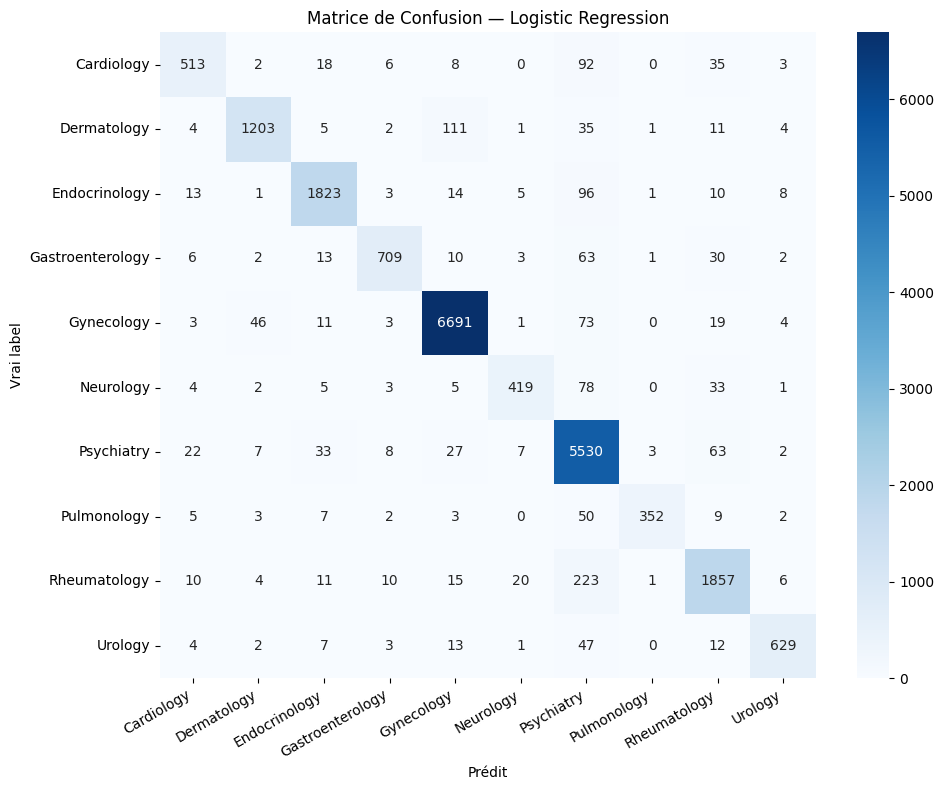

✅ model_ml.pkl sauvegardé


In [31]:
# ── Matrice de confusion ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de Confusion — Logistic Regression")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Sauvegarde
joblib.dump(lr_model, 'model_ml.pkl')
print("✅ model_ml.pkl sauvegardé")

Modèle 2 : Neural Network (Keras)

In [32]:
# ── Tokenisation Keras ───────────────────────────────────────────────────────
VOCAB_SIZE = 20_000
MAX_LEN    = 200
EMBED_DIM  = 64

keras_tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    keras_tok.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_seq = pad_sequences(
    keras_tok.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Séquences train : {X_train_seq.shape}")
print(f"Séquences test  : {X_test_seq.shape}")

Séquences train : (85109, 200)
Séquences test  : (21278, 200)


In [33]:
# ── Architecture ─────────────────────────────────────────────────────────────
tf.random.set_seed(42)

nn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding'),
    GlobalAveragePooling1D(name='pooling'),
    Dense(128, activation='relu', name='dense_1'),
    Dropout(0.3, name='dropout'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='hospital_nn')

nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
nn_model.summary()

Model: "hospital_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling                         │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Entraînement ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)
t0 = time.time()

history = nn_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)
nn_time = time.time() - t0
print(f"✅ Entraîné en {nn_time:.1f}s")

Epoch 1/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.4208 - loss: 1.7355 - val_accuracy: 0.7335 - val_loss: 0.8482
Epoch 2/20
188/566 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7388 - loss: 0.8568

In [ ]:
# ── Courbes d'apprentissage ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['loss', 'accuracy']):
    ax.plot(history.history[metric],     label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Validation')
    ax.set_title(metric.capitalize())
    ax.legend()
plt.suptitle("Courbes d'apprentissage — Neural Network")
plt.tight_layout()
plt.show()

In [ ]:
# ── Évaluation ───────────────────────────────────────────────────────────────
y_pred_nn = np.argmax(nn_model.predict(X_test_seq), axis=1)
nn_acc    = accuracy_score(y_test, y_pred_nn)
nn_f1     = f1_score(y_test, y_pred_nn, average='weighted')

print(f"Accuracy : {nn_acc:.4f}")
print(f"F1-score : {nn_f1:.4f}")
print("\n", classification_report(y_test, y_pred_nn, target_names=le.classes_))

# Sauvegarde modèle + tokenizer
nn_model.save('model_dl.h5')
with open('keras_tokenizer.json', 'w') as f:
    f.write(keras_tok.to_json())
print("✅ model_dl.h5 et keras_tokenizer.json sauvegardés")

Modèle 3 : DistilBERT (HuggingFace)

In [ ]:
# ── Sous-échantillonnage pour Colab gratuit ───────────────────────────────────
# DistilBERT est plus lent → on limite à 5 000 exemples
BERT_N_TRAIN = 5_000
BERT_N_TEST  = 1_000
MAX_LENGTH   = 128

np.random.seed(42)
idx_tr = np.random.choice(len(X_train), BERT_N_TRAIN, replace=False)
idx_te = np.random.choice(len(X_test),  BERT_N_TEST,  replace=False)

Xb_train, yb_train = [X_train[i] for i in idx_tr], y_train[idx_tr]
Xb_test,  yb_test  = [X_test[i]  for i in idx_te], y_test[idx_te]

print(f"DistilBERT — Train : {len(Xb_train)} | Test : {len(Xb_test)}")

In [ ]:
# ── Tokenisation DistilBERT ───────────────────────────────────────────────────
bert_tok = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def encode(texts):
    return bert_tok(
        texts,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='tf'
    )

train_enc = encode(Xb_train)
test_enc  = encode(Xb_test)

ds_train = tf.data.Dataset.from_tensor_slices(
    (dict(train_enc), yb_train)).shuffle(1000).batch(32)
ds_test  = tf.data.Dataset.from_tensor_slices(
    (dict(test_enc),  yb_test)).batch(32)

print("✅ Datasets TF créés")

In [ ]:
# ── Fine-tuning DistilBERT ────────────────────────────────────────────────────
print("Chargement de distilbert-base-uncased...")
bert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=NUM_CLASSES
)

bert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

t0 = time.time()
bert_model.fit(ds_train, epochs=3, validation_data=ds_test, verbose=1)
bert_time = time.time() - t0
print(f"✅ Fine-tuné en {bert_time:.1f}s")

In [ ]:
# ── Évaluation DistilBERT ─────────────────────────────────────────────────────
all_logits = np.concatenate(
    [bert_model(batch[0], training=False).logits.numpy() for batch in ds_test]
)
y_pred_bert = np.argmax(all_logits, axis=1)
bert_acc    = accuracy_score(yb_test, y_pred_bert)
bert_f1     = f1_score(yb_test, y_pred_bert, average='weighted')

print(f"Accuracy : {bert_acc:.4f}")
print(f"F1-score : {bert_f1:.4f}")
print("\n", classification_report(yb_test, y_pred_bert, target_names=le.classes_))

# Sauvegarde
bert_model.save_pretrained('bert_model_dir')
bert_tok.save_pretrained('bert_tokenizer_dir')
print("✅ DistilBERT sauvegardé dans bert_model_dir/")

Tableau Récapitulatif

In [ ]:
results = pd.DataFrame([
    {'Modèle': '1. Logistic Regression',
     'Accuracy': f'{lr_acc:.4f}', 'F1-score': f'{lr_f1:.4f}',
     'Temps (s)': f'{lr_time:.1f}'},
    {'Modèle': '2. Neural Network (Keras)',
     'Accuracy': f'{nn_acc:.4f}', 'F1-score': f'{nn_f1:.4f}',
     'Temps (s)': f'{nn_time:.1f}'},
    {'Modèle': '3. DistilBERT',
     'Accuracy': f'{bert_acc:.4f}', 'F1-score': f'{bert_f1:.4f}',
     'Temps (s)': f'{bert_time:.1f}'},
])

print("=" * 55)
print("    TABLEAU RÉCAPITULATIF DES PERFORMANCES")
print("=" * 55)
print(results.to_string(index=False))

# Visualisation tableau
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
tbl = ax.table(cellText=results.values, colLabels=results.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)
plt.title("Comparaison des 3 modèles", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

Analyse des Erreurs

In [ ]:
# ── 5 mauvaises prédictions (Logistic Regression) ────────────────────────────
err_mask  = y_pred_lr != y_test
err_texts = X_test[err_mask]
err_true  = le.inverse_transform(y_test[err_mask])
err_pred  = le.inverse_transform(y_pred_lr[err_mask])

print(f"Total erreurs : {err_mask.sum()} / {len(y_test)}")
print(f"Taux d'erreur : {err_mask.mean()*100:.2f}%\n")

for i in range(min(5, len(err_texts))):
    print(f"─── Erreur #{i+1} ───────────────────────────────────")
    print(f"Texte     : {err_texts[i][:250]}")
    print(f"Réel      : {err_true[i]}")
    print(f"Prédit    : {err_pred[i]}")
    nb_mots = len(err_texts[i].split())
    if nb_mots < 8:
        cause = "Texte trop court → manque d'information"
    elif err_true[i] in ('Psychiatry', 'Rheumatology') and \
         err_pred[i] in ('Psychiatry', 'Rheumatology'):
        cause = "Chevauchement sémantique entre services proches"
    else:
        cause = "Ambiguïté linguistique ou symptômes communs à plusieurs services"
    print(f"Analyse   : {cause}\n")

In [ ]:
# ── Paires de confusion les plus fréquentes ──────────────────────────────────
err_df = pd.DataFrame({'Réel': err_true, 'Prédit': err_pred})
top_confusions = (err_df
    .groupby(['Réel', 'Prédit'])
    .size()
    .reset_index(name='Nb erreurs')
    .sort_values('Nb erreurs', ascending=False)
    .head(10))

print("Top 10 paires de confusion :")
print(top_confusions.to_string(index=False))

Vérification des artefacts exportés

In [ ]:
# ── Liste des fichiers générés ────────────────────────────────────────────────
artefacts = [
    'model_ml.pkl',
    'tfidf_vectorizer.pkl',
    'label_encoder.pkl',
    'model_dl.h5',
    'keras_tokenizer.json',
]

print("=" * 50)
print("  ARTEFACTS EXPORTÉS")
print("=" * 50)
for f in artefacts:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✅ {f:<30s} {size_kb:7.1f} KB")
    else:
        print(f"  ❌ {f:<30s} MANQUANT")

print("\n🎉 Notebook terminé !")
print("→ Copier les 3 fichiers .pkl dans le dossier models/ de l'app Streamlit")
print("  • model_ml.pkl")
print("  • tfidf_vectorizer.pkl")
print("  • label_encoder.pkl")